# 01 — Data, SQL and EDA
For the full workflow, open `Customer_Churn_Complete.ipynb`. This notebook focuses on data understanding.

In [1]:
from pathlib import Path
import sqlite3, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=='folder2' else Path.cwd()
df=pd.read_csv(ROOT/'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce'); df['Churn']=df['Churn'].map({'Yes':1,'No':0})
df['tenure_group']=pd.cut(df.tenure,[-1,5,11,23,47,999],labels=['0-5','6-11','12-23','24-47','48+'])
display(df.head()); print(df.shape); print(f'Churn rate: {df.Churn.mean():.2%}')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-5
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,24-47
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-5
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,24-47
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-5


(7043, 22)
Churn rate: 26.54%


In [2]:
db=sqlite3.connect(':memory:'); df.to_sql('customers',db,index=False)
display(pd.read_sql_query('SELECT COUNT(*) customers, SUM(Churn) churned, ROUND(100*AVG(Churn),2) churn_rate_pct FROM customers',db))
display(pd.read_sql_query('SELECT Contract, COUNT(*) customers, ROUND(100*AVG(Churn),2) churn_rate_pct FROM customers GROUP BY Contract',db))

,customers,churned,churn_rate_pct
0,7043,1869,26.54


,Contract,customers,churn_rate_pct
0,Month-to-month,3875,42.71
1,One year,1473,11.27
2,Two year,1695,2.83


,count,mean
Contract,,
Month-to-month,3875,0.427097
One year,1473,0.112695
Two year,1695,0.028319


,count,mean
PaymentMethod,,
Electronic check,2365,0.452854
Mailed check,1612,0.191067
Bank transfer (automatic),1544,0.167098
Credit card (automatic),1522,0.152431


,count,mean
InternetService,,
Fiber optic,3096,0.418928
DSL,2421,0.189591
No,1526,0.074050


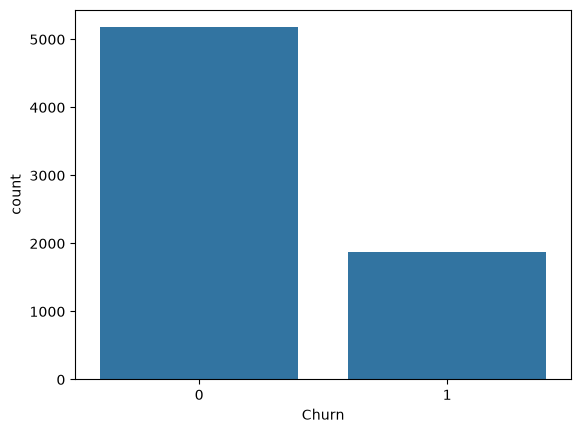

In [3]:
for col in ['Contract','PaymentMethod','InternetService']:
    display(df.groupby(col)['Churn'].agg(['count','mean']).sort_values('mean',ascending=False))
sns.countplot(data=df,x='Churn'); plt.show()